In [6]:
from pathlib import Path
import json

biomass_root = Path(r"C:\Users\danie\Desktop\Treefera Hackathon\data\biomass")

for results_file in biomass_root.rglob("results.json"):
    print("\n===", results_file, "===")
    with open(results_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    print(type(data))
    if isinstance(data, dict):
        print("Keys:", list(data.keys()))
        print(json.dumps(data, indent=2)[:2000])
    else:
        print(str(data)[:2000])


=== C:\Users\danie\Desktop\Treefera Hackathon\data\biomass\above-ground-biomass\results.json ===
<class 'dict'>
Keys: ['analysis_id', 'location_id', 'status', 'submitted_at', 'links', 'completed_at', 'error', 'analysis_params', 'results']
{
  "analysis_id": "31c0029a-77e8-4e71-a000-e7a2dbc64124",
  "location_id": "8c1b42ce-9524-4f2e-9ca2-83cbbd4e9812",
  "status": "COMPLETED",
  "submitted_at": "2026-06-23T13:51:55.025622Z",
  "links": {
    "self": "/v1/above-ground-biomass/analyses/31c0029a-77e8-4e71-a000-e7a2dbc64124",
    "status": "/v1/above-ground-biomass/analyses/31c0029a-77e8-4e71-a000-e7a2dbc64124/status",
    "results": "/v1/above-ground-biomass/analyses/31c0029a-77e8-4e71-a000-e7a2dbc64124",
    "retry": null
  },
  "completed_at": "2026-06-23T13:58:19.190253Z",
  "error": null,
  "analysis_params": {
    "target_years": [
      2007,
      2010,
      2015,
      2016,
      2017,
      2018,
      2019,
      2020,
      2021,
      2022
    ]
  },
  "results": {
    "key

C:\Users\danie\AppData\Local\Temp\ipykernel_14940\3987466319.py:17: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype("float32")


,category,year,file,mean,median,valid_pixels
0,above-ground,2007,esa_biomass_agb_cog_CLIENT_61785376_2007.tif,4.415443,0.000000,9130
1,above-ground,2010,esa_biomass_agb_cog_CLIENT_61785376_2010.tif,4.271851,0.000000,9130
2,above-ground,2015,esa_biomass_agb_cog_CLIENT_61785376_2015.tif,6.456079,0.000000,9130
3,above-ground,2016,esa_biomass_agb_cog_CLIENT_61785376_2016.tif,12.373275,1.000000,9130
4,above-ground,2017,esa_biomass_agb_cog_CLIENT_61785376_2017.tif,6.261446,0.000000,9130
5,above-ground,2018,esa_biomass_agb_cog_CLIENT_61785376_2018.tif,3.933735,0.000000,9130
6,above-ground,2019,esa_biomass_agb_cog_CLIENT_61785376_2019.tif,5.463965,0.000000,9130
7,above-ground,2020,esa_biomass_agb_cog_CLIENT_61785376_2020.tif,9.386199,0.000000,9130
8,above-ground,2021,esa_biomass_agb_cog_CLIENT_61785376_2021.tif,2.318839,0.000000,9130
9,above-ground,2022,esa_biomass_agb_cog_CLIENT_61785376_2022.tif,3.512815,0.000000,9130


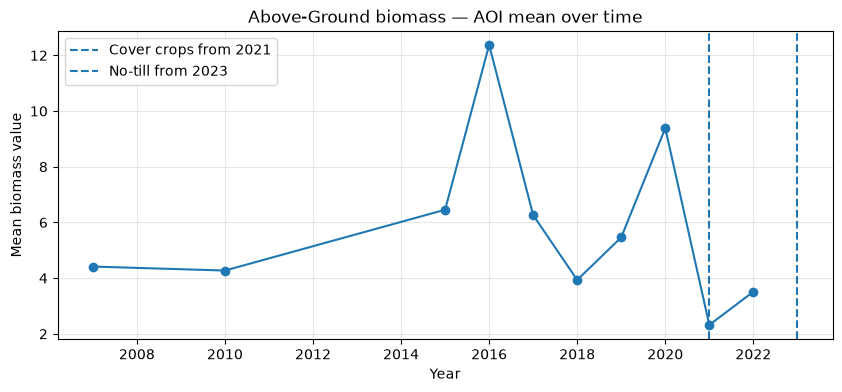

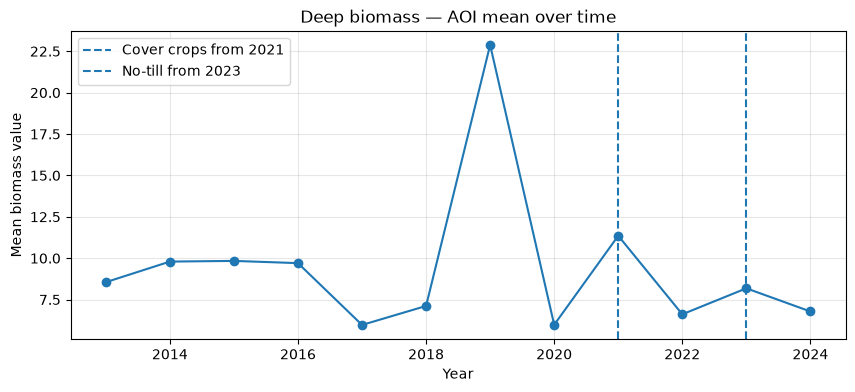

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
import rasterio

rows = []

for p in sorted(Path(r"C:\Users\danie\Desktop\Treefera Hackathon\data\biomass").rglob("*.tif")):
    year_match = re.search(r"(20\d{2})", p.name)
    year = int(year_match.group(1)) if year_match else None
    
    category = "above-ground" if "above-ground" in str(p).lower() else "deep"
    
    with rasterio.open(p) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
        arr = np.where(np.isfinite(arr), arr, np.nan)
        
        rows.append({
            "category": category,
            "year": year,
            "file": p.name,
            "mean": float(np.nanmean(arr)),
            "median": float(np.nanmedian(arr)),
            "valid_pixels": int(np.isfinite(arr).sum())
        })

bio_df = pd.DataFrame(rows).sort_values(["category", "year"])
display(bio_df)

for category, group in bio_df.groupby("category"):
    plt.figure(figsize=(10, 4))
    plt.plot(group["year"], group["mean"], marker="o")
    plt.axvline(2021, linestyle="--", label="Cover crops from 2021")
    plt.axvline(2023, linestyle="--", label="No-till from 2023")
    plt.title(f"{category.title()} biomass — AOI mean over time")
    plt.xlabel("Year")
    plt.ylabel("Mean biomass value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr

BASELINE_DATE = np.datetime64("2022-01-25")

def harmonise_s2_band(band):
    band = band.astype("float32")
    corrected_after_baseline = (band - 1000).clip(min=0)
    return xr.where(band["time"] >= BASELINE_DATE, corrected_after_baseline, band)

red = harmonise_s2_band(ds["B04"])
nir = harmonise_s2_band(ds["B08"])

ndvi = (nir - red) / (nir + red)
ndvi = ndvi.where(np.isfinite(ndvi))

mean_ndvi = ndvi.mean(dim=("x", "y"), skipna=True).compute()

ndvi_df = mean_ndvi.to_dataframe(name="ndvi").reset_index()

if "spatial_ref" in ndvi_df.columns:
    ndvi_df = ndvi_df.drop(columns=["spatial_ref"])

ndvi_df["time"] = pd.to_datetime(ndvi_df["time"]).dt.strftime("%Y-%m-%d")
ndvi_df["scope"] = "aoi_mean"
ndvi_df["method"] = "sentinel2_baseline_harmonised"
ndvi_df["note"] = "AOI-level sanity check, not field-level proof"

out = Path(r"C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_timeseries.json")
out.parent.mkdir(parents=True, exist_ok=True)
ndvi_df.to_json(out, orient="records", indent=2)

print("Saved:", out)
display(ndvi_df.head())
display(ndvi_df.tail())

C:\Users\danie\Desktop\Treefera Hackathon\.venv\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_timeseries.json


,time,ndvi,scope,method,note
0,2017-01-01,0.291454,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
1,2017-02-01,0.173636,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
2,2017-03-01,0.239216,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
3,2017-04-01,0.362733,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
4,2017-05-01,0.369635,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"


,time,ndvi,scope,method,note
103,2025-08-01,0.785555,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
104,2025-09-01,0.510303,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
105,2025-10-01,0.360030,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
106,2025-11-01,0.318755,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"
107,2025-12-01,0.172023,aoi_mean,sentinel2_baseline_harmonised,"AOI-level sanity check, not field-level proof"


In [11]:
from pathlib import Path
import pandas as pd
import json

ndvi_path = Path(r"C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_timeseries.json")
out_path = Path(r"C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_summary.json")

df = pd.read_json(ndvi_path)
df["time"] = pd.to_datetime(df["time"])
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month

# Focus on growing season to avoid winter noise
growing = df[df["month"].isin([6, 7, 8, 9])].copy()

periods = {
    "pre_adoption_2017_2020": growing[(growing["year"] >= 2017) & (growing["year"] <= 2020)],
    "cover_crop_period_2021_2022": growing[(growing["year"] >= 2021) & (growing["year"] <= 2022)],
    "no_till_period_2023_2025": growing[(growing["year"] >= 2023) & (growing["year"] <= 2025)],
}

summary = {
    "method": "Sentinel-2 B08/B04 NDVI with baseline harmonisation: subtract 1000 from optical bands on/after 2022-01-25, clamp at 0",
    "scope": "AOI-level growing-season sanity check",
    "warning": "Not field-level proof. Target/control polygons or manual ROIs are still required for a credible Roger-vs-neighbour comparison.",
    "periods": {}
}

for name, subset in periods.items():
    summary["periods"][name] = {
        "mean_ndvi": None if subset["ndvi"].dropna().empty else round(float(subset["ndvi"].mean()), 4),
        "median_ndvi": None if subset["ndvi"].dropna().empty else round(float(subset["ndvi"].median()), 4),
        "max_ndvi": None if subset["ndvi"].dropna().empty else round(float(subset["ndvi"].max()), 4),
        "observations": int(subset["ndvi"].notna().sum())
    }

out_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Saved:", out_path)
print(json.dumps(summary, indent=2))

Saved: C:\Users\danie\Desktop\Treefera Hackathon\public\demo-data\ndvi_summary.json
{
  "method": "Sentinel-2 B08/B04 NDVI with baseline harmonisation: subtract 1000 from optical bands on/after 2022-01-25, clamp at 0",
  "scope": "AOI-level growing-season sanity check",
  "warning": "Not field-level proof. Target/control polygons or manual ROIs are still required for a credible Roger-vs-neighbour comparison.",
  "periods": {
    "pre_adoption_2017_2020": {
      "mean_ndvi": 0.6078,
      "median_ndvi": 0.6535,
      "max_ndvi": 0.7658,
      "observations": 16
    },
    "cover_crop_period_2021_2022": {
      "mean_ndvi": 0.621,
      "median_ndvi": 0.6648,
      "max_ndvi": 0.7508,
      "observations": 8
    },
    "no_till_period_2023_2025": {
      "mean_ndvi": 0.6814,
      "median_ndvi": 0.7357,
      "max_ndvi": 0.7856,
      "observations": 12
    }
  }
}
